# **Baseline Models Implementations**

In [5]:
"""
Baseline classification models: does AI-disclosure decrease purchase intention?
Thesis: The Influence of AI-Generated versus Human-Created Digital Marketing on
GCC Gen Z Purchase Intention: A Machine Learning and Sentiment Analysis Approach

PART 1: Sentiment Analysis Baseline
  - TF-IDF + Logistic Regression
  - TF-IDF + Linear SVM
  Target: Sentiment labels (Negative/Neutral/Positive) from text responses

PART 2: Purchase Intention Baseline
Three models are used, in increasing order of complexity, all easy to explain in a viva:
  1. Logistic Regression - each feature has a weight (+/-) on the odds of the outcome.
  2. Decision Tree        - a flowchart of yes/no questions ending in a prediction.
  3. Random Forest        - many decision trees voting together (an ensemble).

Target variable: Q25, collapsed to binary.
  1 = "disclosure would DECREASE my purchase intention"
  0 = "disclosure would keep it the same or increase it"

Features: demographics (age, country, gender, spend) + AI literacy (Q7/Q8) +
trust (Q9) + privacy discomfort (Q11/Q12) + emotional/context/AI-visual items (Q26-Q28).
"""

import pandas as pd
import numpy as nmp
import matplotlib.pyplot as pyplt_
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.tree import export_text
import warnings
warnings.filterwarnings('ignore')

# Set style
pyplt_.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

---------------------------------------------------
# **PART 1: SENTIMENT ANALYSIS BASELINE**
TF-IDF + Logistic Regression & TF-IDF + Linear SVM
---------------------------------------------------


In [6]:
print("PART 1: SENTIMENT ANALYSIS BASELINE")
print("TF-IDF + Logistic Regression & TF-IDF + Linear SVM")
# Load sentiment dataset
sentimentDataset_df = pd.read_excel("sentiment_dataset.xlsx")
print(f"\nSentiment dataset shape: {sentimentDataset_df.shape}")
# Prepare features and target
Xsent = sentimentDataset_df['text']
ySent_ = sentimentDataset_df['label']

print(f"\nSentiment distribution:")
print(sentimentDataset_df['sentiment'].value_counts())
# Get actual classes present in data
getActualClasses_ = sorted(ySent_.unique())
getClassNames_ = ['Negative', 'Neutral', 'Positive']
actClassNames = [getClassNames_[i] for i in getActualClasses_]

print(f"\nActual classes present: {actClassNames}")

PART 1: SENTIMENT ANALYSIS BASELINE
TF-IDF + Logistic Regression & TF-IDF + Linear SVM

Sentiment dataset shape: (276, 7)

Sentiment distribution:
sentiment
positive    255
negative     12
neutral       9
Name: count, dtype: int64

Actual classes present: ['Negative', 'Neutral', 'Positive']


**Train/test split**

In [7]:
# Train/test split
XsentTrain, XsentTest_, ySentTrain, ySentTest = train_test_split(
    Xsent, ySent_, test_size=0.20, random_state=42, stratify=ySent_
)

print(f"\nTraining set: {len(XsentTrain)} samples")
print(f"Test set: {len(XsentTest_)} samples")


Training set: 220 samples
Test set: 56 samples


**TF-IDF Vectorization**

In [8]:
# TF-IDF Vectorization
resTD_IDF_ = TfidfVectorizer(
    max_features=1500,
    stop_words='english',
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.8
)

XsentTrain_tf_idf = resTD_IDF_.fit_transform(XsentTrain)
XsentTest_tf_idf_ = resTD_IDF_.transform(XsentTest_)

print(f"\nTF-IDF feature matrix: {XsentTrain_tf_idf.shape}")
print(f"Number of features: {len(resTD_IDF_.get_feature_names_out())}")


TF-IDF feature matrix: (220, 213)
Number of features: 213


**Class weights for imbalance**

In [9]:
# Class weights for imbalance
setClassSenti = nmp.unique(ySentTrain)
setClassWeightsSenti_ = compute_class_weight('balanced', classes=setClassSenti, y=ySentTrain)
dictClassWeightSenti_ = dict(zip(setClassSenti, setClassWeightsSenti_))

print("\nClass weights for sentiment analysis:")
for c, w in dictClassWeightSenti_.items():
    s = getClassNames_[c]
    print(f"  {s} (class {c}): {w:.3f}")


Class weights for sentiment analysis:
  Negative (class 0): 7.333
  Neutral (class 1): 10.476
  Positive (class 2): 0.361


# **Model 1: TF-IDF + Logistic Regression**

In [10]:
# --- Model 1: TF-IDF + Logistic Regression ---
print("\n" + "-" * 80)
print("MODEL 1: TF-IDF + LOGISTIC REGRESSION")


LR_Mod_senti = LogisticRegression(
    class_weight=dictClassWeightSenti_,
    max_iter=1000,
    random_state=42,
    C=1.0,
    multi_class='multinomial',
    solver='lbfgs'
)
LR_Mod_senti.fit(XsentTrain_tf_idf, ySentTrain)
yPredLinearReg_Senti = LR_Mod_senti.predict(XsentTest_tf_idf_)

# Metrics
getAcc_linearReg_sent = accuracy_score(ySentTest, yPredLinearReg_Senti)
prec__linearReg_senti = precision_score(ySentTest, yPredLinearReg_Senti, average='weighted', zero_division=0)
rec__linearReg_senti = recall_score(ySentTest, yPredLinearReg_Senti, average='weighted', zero_division=0)
f1__linearReg_senti = f1_score(ySentTest, yPredLinearReg_Senti, average='weighted', zero_division=0)

cv_scores__linearReg_senti = cross_val_score(LR_Mod_senti, XsentTrain_tf_idf, ySentTrain, cv=5)

print(f"\nTest Set Performance:")
print(f"  Accuracy:  {getAcc_linearReg_sent:.4f}")
print(f"  Precision: {prec__linearReg_senti:.4f}")
print(f"  Recall:    {rec__linearReg_senti:.4f}")
print(f"  F1-Score:  {f1__linearReg_senti:.4f}")
print(f"\n5-Fold CV: {cv_scores__linearReg_senti.mean():.4f} (±{cv_scores__linearReg_senti.std():.4f})")

# Get unique classes in test set
getTestClasses_ = nmp.unique(ySentTest)
testClassNames_ = [getClassNames_[i] for i in getTestClasses_]

print(f"\nClassification Report (classes present in test set: {testClassNames_}):")
print(classification_report(ySentTest, yPredLinearReg_Senti,
                          labels=getTestClasses_,
                          target_names=testClassNames_,
                          zero_division=0))

print(f"\nConfusion Matrix:")
conMat_linarReg_ = confusion_matrix(ySentTest, yPredLinearReg_Senti)
conMat_linarReg_df = pd.DataFrame(conMat_linarReg_,
                        index=[f'True {getClassNames_[i]}' for i in getTestClasses_],
                        columns=[f'Pred {getClassNames_[i]}' for i in getTestClasses_])
print(conMat_linarReg_df)


--------------------------------------------------------------------------------
MODEL 1: TF-IDF + LOGISTIC REGRESSION

Test Set Performance:
  Accuracy:  0.8214
  Precision: 0.9447
  Recall:    0.8214
  F1-Score:  0.8654

5-Fold CV: 0.8636 (±0.0593)

Classification Report (classes present in test set: ['Negative', 'Neutral', 'Positive']):
              precision    recall  f1-score   support

    Negative       0.29      1.00      0.44         2
     Neutral       0.17      0.50      0.25         2
    Positive       1.00      0.83      0.91        52

    accuracy                           0.82        56
   macro avg       0.48      0.78      0.53        56
weighted avg       0.94      0.82      0.87        56


Confusion Matrix:
               Pred Negative  Pred Neutral  Pred Positive
True Negative              2             0              0
True Neutral               1             1              0
True Positive              4             5             43


# **Model 2: TF-IDF + Linear SVM**

In [11]:
print("\n" + "-" * 80)
print("MODEL 2: TF-IDF + LINEAR SVM")
SVM_Mod_senti = LinearSVC(
    class_weight='balanced',
    max_iter=1000,
    random_state=42,
    C=1.0,
    dual=False
)
SVM_Mod_senti.fit(XsentTrain_tf_idf, ySentTrain)
yPred_SVM_senti_ = SVM_Mod_senti.predict(XsentTest_tf_idf_)

# Metrics
accSVM_senti_ = accuracy_score(ySentTest, yPred_SVM_senti_)
precSVM_senti_ = precision_score(ySentTest, yPred_SVM_senti_, average='weighted', zero_division=0)
recSVM_senti_ = recall_score(ySentTest, yPred_SVM_senti_, average='weighted', zero_division=0)
f1SVM_senti_ = f1_score(ySentTest, yPred_SVM_senti_, average='weighted', zero_division=0)
cvScoresSVM_senti_ = cross_val_score(SVM_Mod_senti, XsentTrain_tf_idf, ySentTrain, cv=5)
print(f"\nTest Set Performance:")
print(f"  Accuracy:  {accSVM_senti_:.4f}")
print(f"  Precision: {precSVM_senti_:.4f}")
print(f"  Recall:    {recSVM_senti_:.4f}")
print(f"  F1-Score:  {f1SVM_senti_:.4f}")
print(f"\n5-Fold CV: {cvScoresSVM_senti_.mean():.4f} (±{cvScoresSVM_senti_.std():.4f})")

print(f"\nClassification Report (classes present in test set: {testClassNames_}):")
print(classification_report(ySentTest, yPred_SVM_senti_,
                          labels=getTestClasses_,
                          target_names=testClassNames_,
                         zero_division=0))

print(f"\nConfusion Matrix:")
conMatSVM_ = confusion_matrix(ySentTest, yPred_SVM_senti_)
conMatSVM_df = pd.DataFrame(conMatSVM_,
                        index=[f'True {getClassNames_[i]}' for i in getTestClasses_],
                        columns=[f'Pred {getClassNames_[i]}' for i in getTestClasses_])
print(conMatSVM_df)


--------------------------------------------------------------------------------
MODEL 2: TF-IDF + LINEAR SVM

Test Set Performance:
  Accuracy:  0.9464
  Precision: 0.9520
  Recall:    0.9464
  F1-Score:  0.9480

5-Fold CV: 0.9364 (±0.0265)

Classification Report (classes present in test set: ['Negative', 'Neutral', 'Positive']):
              precision    recall  f1-score   support

    Negative       0.67      1.00      0.80         2
     Neutral       0.50      0.50      0.50         2
    Positive       0.98      0.96      0.97        52

    accuracy                           0.95        56
   macro avg       0.72      0.82      0.76        56
weighted avg       0.95      0.95      0.95        56


Confusion Matrix:
               Pred Negative  Pred Neutral  Pred Positive
True Negative              2             0              0
True Neutral               0             1              1
True Positive              1             1             50


# **Sentiment Model Comparison**

In [12]:
print("SENTIMENT ANALYSIS MODEL COMPARISON")
sentiComparison_ = pd.DataFrame({
    'Model': ['TF-IDF + Logistic Regression', 'TF-IDF + Linear SVM'],
    'Accuracy': [getAcc_linearReg_sent, accSVM_senti_],
    'Precision': [prec__linearReg_senti, precSVM_senti_],
    'Recall': [rec__linearReg_senti, recSVM_senti_],
    'F1-Score': [f1__linearReg_senti, f1SVM_senti_],
    'CV Accuracy': [cv_scores__linearReg_senti.mean(), cvScoresSVM_senti_.mean()]
})
print(sentiComparison_.to_string(index=False, float_format=lambda x: '{:.4f}'.format(x)))

bestSentiModel_ = 'Linear SVM' if accSVM_senti_ >= getAcc_linearReg_sent else 'Logistic Regression'
bestSentiAcc_ = max(getAcc_linearReg_sent, accSVM_senti_)
print(f"\nBest Sentiment Model: {bestSentiModel_} with {bestSentiAcc_:.4f} accuracy")


SENTIMENT ANALYSIS MODEL COMPARISON
                       Model  Accuracy  Precision  Recall  F1-Score  CV Accuracy
TF-IDF + Logistic Regression    0.8214     0.9447  0.8214    0.8654       0.8636
         TF-IDF + Linear SVM    0.9464     0.9520  0.9464    0.9480       0.9364

Best Sentiment Model: Linear SVM with 0.9464 accuracy


 ---------------------------------------------------
# **PART 2: PURCHASE INTENTION BASELINE**
 Logistic Regression, Decision Tree, Random Forest
 ---------------------------------------------------


**Load cleaned survey data**

In [13]:
print("PART 2: PURCHASE INTENTION BASELINE")
print("Logistic Regression, Decision Tree, Random Forest")
# Load cleaned survey data
surveyCleaned_DF_ = pd.read_excel("survey_cleaned.xlsx")
print(f"\nCleaned survey dataset: {surveyCleaned_DF_.shape[0]} rows, {surveyCleaned_DF_.shape[1]} columns")

# Define variables
TARGET = "ai_label_effect"
TRUST = "ai_trust"
PRIVACY1 = "privacy_invasion"
PRIVACY2 = "privacy_unease"
EMOTIONAL = "emotion_impact"
CONTEXT = "timing_effect"
AI_VISUALS = "visual_misrep_effect"
LITERACY1 = "ai_familiarity"
LITERACY2 = "ai_detection"
AGE = "age_group"
COUNTRY = "country"
GENDER = "gender"
SPEND = "monthly_spend"

# Create target
surveyCleaned_DF_["target"] = (surveyCleaned_DF_[TARGET] == "Decrease").astype(int)

# Remove missing target
surveyCleaned_DF_ = surveyCleaned_DF_[surveyCleaned_DF_[TARGET].notna()].copy()

# Build features
Xpurchase_ = pd.DataFrame(index=surveyCleaned_DF_.index)

# Controls
Xpurchase_["age"] = LabelEncoder().fit_transform(surveyCleaned_DF_[AGE].astype(str))
Xpurchase_["spend"] = LabelEncoder().fit_transform(surveyCleaned_DF_[SPEND].astype(str))

# One-hot encode country and gender
country_dummies = pd.get_dummies(surveyCleaned_DF_[COUNTRY].astype(str), prefix="country", drop_first=True)
Xpurchase_ = Xpurchase_.join(country_dummies)

gender_dummies = pd.get_dummies(surveyCleaned_DF_[GENDER].astype(str), prefix="gender", drop_first=True)
Xpurchase_ = Xpurchase_.join(gender_dummies)

# Moderator
Xpurchase_["literacy"] = surveyCleaned_DF_[[LITERACY1, LITERACY2]].mean(axis=1)

# Organism variables
Xpurchase_["trust"] = surveyCleaned_DF_[TRUST]
Xpurchase_["privacy"] = surveyCleaned_DF_[[PRIVACY1, PRIVACY2]].mean(axis=1)
Xpurchase_["emotional"] = surveyCleaned_DF_[EMOTIONAL]
Xpurchase_["context"] = surveyCleaned_DF_[CONTEXT]
Xpurchase_["ai_edited_visuals"] = surveyCleaned_DF_[AI_VISUALS]

# Target
yPurchaseTarget = surveyCleaned_DF_["target"]

# Remove missing
validRows_ = Xpurchase_.notna().all(axis=1)
Xpurchase_ = Xpurchase_[validRows_]
yPurchaseTarget = yPurchaseTarget[validRows_]

print(f"\nFinal feature matrix: {Xpurchase_.shape}")
print(f"Features: {Xpurchase_.columns.tolist()}")

PART 2: PURCHASE INTENTION BASELINE
Logistic Regression, Decision Tree, Random Forest

Cleaned survey dataset: 276 rows, 43 columns

Final feature matrix: (276, 14)
Features: ['age', 'spend', 'country_Kuwait', 'country_Oman', 'country_Qatar', 'country_Saudi Arabia', 'country_UAE', 'gender_Male', 'literacy', 'trust', 'privacy', 'emotional', 'context', 'ai_edited_visuals']


**Train/test split**

In [14]:
# Train/test split
XpurchaseTrain, XpurchaseTest, yPurchaseTrain, yPurchaseTest = train_test_split(
    Xpurchase_, yPurchaseTarget, test_size=0.20, stratify=yPurchaseTarget, random_state=42
)

print(f"\nTraining set: {len(XpurchaseTrain)} samples")
print(f"Test set: {len(XpurchaseTest)} samples")

# Class weights
clsPurchase = nmp.unique(yPurchaseTrain)
cls_weightsPurchase = compute_class_weight('balanced', classes=clsPurchase, y=yPurchaseTrain)
dictClsWeightPurchase_ = dict(zip(clsPurchase, cls_weightsPurchase))

print("\nClass weights for purchase intention:")
for c, w in dictClsWeightPurchase_.items():
    l = 'Not Decrease' if c == 0 else 'Decrease'
    print(f"  {l} (class {c}): {w:.3f}")


Training set: 220 samples
Test set: 56 samples

Class weights for purchase intention:
  Not Decrease (class 0): 1.146
  Decrease (class 1): 0.887


**Models**

In [15]:
# Initialize models
purchaseModels_ = {
    "Logistic Regression": LogisticRegression(
        class_weight=dictClsWeightPurchase_,
        max_iter=1000,
        random_state=42
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=4,
        random_state=42,
        class_weight='balanced'
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=5,
        random_state=42,
        class_weight='balanced'
    ),
}

print("\nModels initialized:")
for name in purchaseModels_.keys():
    print(f"  {name}")

# Train and evaluate
print("\n" + "-" * 80)
print("PURCHASE INTENTION MODEL RESULTS")


setPurchaseResults_ = {}

for n, m in purchaseModels_.items():
    print(f"\n{'='*60}")
    print(f"MODEL: {n}")
    print(f"{'='*60}")

    m.fit(XpurchaseTrain, yPurchaseTrain)
    pred = m.predict(XpurchaseTest)

    getAcc = accuracy_score(yPurchaseTest, pred)
    getprec = precision_score(yPurchaseTest, pred, zero_division=0)
    getrec = recall_score(yPurchaseTest, pred, zero_division=0)
    getf1 = f1_score(yPurchaseTest, pred, zero_division=0)

    getcv_scores = cross_val_score(m, Xpurchase_, yPurchaseTarget, cv=5)

    setPurchaseResults_[n] = {
        'accuracy': getAcc,
        'precision': getprec,
        'recall': getrec,
        'f1': getf1,
        'cv_mean': getcv_scores.mean(),
        'cv_std': getcv_scores.std()
    }

    print(f"\nTest Set Performance:")
    print(f"  Accuracy:  {getAcc:.3f}")
    print(f"  Precision: {getprec:.3f}")
    print(f"  Recall:    {getrec:.3f}")
    print(f"  F1-Score:  {getf1:.3f}")
    print(f"\n5-Fold CV: {getcv_scores.mean():.3f} (±{getcv_scores.std():.3f})")
    print(f"\nConfusion Matrix:")
    getcm = confusion_matrix(yPurchaseTest, pred)
    print(pd.DataFrame(getcm, index=['True 0', 'True 1'], columns=['Pred 0', 'Pred 1']))
    print(f"\nClassification Report:")
    print(classification_report(yPurchaseTest, pred, target_names=['Not Decrease', 'Decrease']))



Models initialized:
  Logistic Regression
  Decision Tree
  Random Forest

--------------------------------------------------------------------------------
PURCHASE INTENTION MODEL RESULTS

MODEL: Logistic Regression

Test Set Performance:
  Accuracy:  0.589
  Precision: 0.655
  Recall:    0.594
  F1-Score:  0.623

5-Fold CV: 0.572 (±0.061)

Confusion Matrix:
        Pred 0  Pred 1
True 0      14      10
True 1      13      19

Classification Report:
              precision    recall  f1-score   support

Not Decrease       0.52      0.58      0.55        24
    Decrease       0.66      0.59      0.62        32

    accuracy                           0.59        56
   macro avg       0.59      0.59      0.59        56
weighted avg       0.60      0.59      0.59        56


MODEL: Decision Tree

Test Set Performance:
  Accuracy:  0.589
  Precision: 0.622
  Recall:    0.719
  F1-Score:  0.667

5-Fold CV: 0.526 (±0.060)

Confusion Matrix:
        Pred 0  Pred 1
True 0      10      14
True

**Purchase Intention Model Comparison**

In [16]:
print("PURCHASE INTENTION MODEL COMPARISON")
purchaseComp_ = pd.DataFrame({
    'Model': list(setPurchaseResults_.keys()),
    'Accuracy': [setPurchaseResults_[m]['accuracy'] for m in setPurchaseResults_],
    'Precision': [setPurchaseResults_[m]['precision'] for m in setPurchaseResults_],
    'Recall': [setPurchaseResults_[m]['recall'] for m in setPurchaseResults_],
    'F1': [setPurchaseResults_[m]['f1'] for m in setPurchaseResults_],
    'CV Accuracy': [setPurchaseResults_[m]['cv_mean'] for m in setPurchaseResults_]
})
print(purchaseComp_.to_string(index=False, float_format=lambda x: '{:.3f}'.format(x)))

bestPurchaseMod = purchaseComp_.loc[purchaseComp_['Accuracy'].idxmax(), 'Model']
bestPurchaseAcc = purchaseComp_['Accuracy'].max()
print(f"\n Best Purchase Intention Model: {bestPurchaseMod} with {bestPurchaseAcc:.3f} accuracy")


PURCHASE INTENTION MODEL COMPARISON
              Model  Accuracy  Precision  Recall    F1  CV Accuracy
Logistic Regression     0.589      0.655   0.594 0.623        0.572
      Decision Tree     0.589      0.622   0.719 0.667        0.526
      Random Forest     0.589      0.655   0.594 0.623        0.572

 Best Purchase Intention Model: Logistic Regression with 0.589 accuracy


**Visualization: ACCURACY BAR CHART - ALL MODELS**

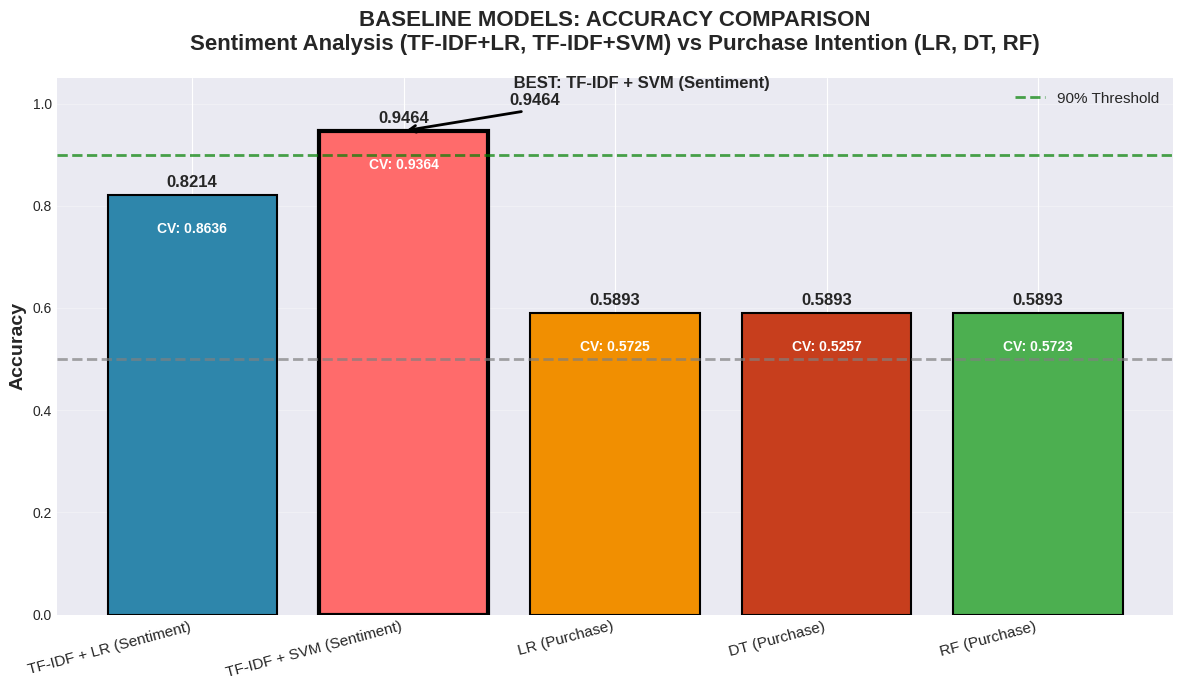

In [17]:
# Collect all getAcc_res_
setModNames_ = [
    'TF-IDF + LR (Sentiment)',
    'TF-IDF + SVM (Sentiment)',
    'LR (Purchase)',
    'DT (Purchase)',
    'RF (Purchase)'
]

getAcc_res_ = [
    getAcc_linearReg_sent,
    accSVM_senti_,
    setPurchaseResults_['Logistic Regression']['accuracy'],
    setPurchaseResults_['Decision Tree']['accuracy'],
    setPurchaseResults_['Random Forest']['accuracy']
]

# Colors for createBars_
setColors_ = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#4CAF50']

# Highlight best model
bestIndx_ = nmp.argmax(getAcc_res_)

#figure
fig, ax = pyplt_.subplots(figsize=(12, 7))

#chart
createBars_ = ax.bar(setModNames_, getAcc_res_, color=setColors_, edgecolor='black', linewidth=1.5)

# bar
createBars_[bestIndx_].set_color('#FF6B6B')
createBars_[bestIndx_].set_edgecolor('black')
createBars_[bestIndx_].set_linewidth(3)

# Add value labels on bars
for b, v in zip(createBars_, getAcc_res_):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01,
             f'{v:.4f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

#  labels
getCvAcc_ = [
    cv_scores__linearReg_senti.mean(),
    cvScoresSVM_senti_.mean(),
    setPurchaseResults_['Logistic Regression']['cv_mean'],
    setPurchaseResults_['Decision Tree']['cv_mean'],
    setPurchaseResults_['Random Forest']['cv_mean']
]

for i, (b, cv) in enumerate(zip(createBars_, getCvAcc_)):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() - 0.08,
             f'CV: {cv:.4f}', ha='center', va='bottom', fontsize=10,
             color='white', fontweight='bold')

ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.7, linewidth=2)
ax.axhline(y=0.9, color='green', linestyle='--', alpha=0.7, linewidth=2, label='90% Threshold')

#  chart
ax.set_ylim(0, 1.05)
ax.set_ylabel('Accuracy', fontsize=14, fontweight='bold')
ax.set_title('BASELINE MODELS: ACCURACY COMPARISON\n'
             'Sentiment Analysis (TF-IDF+LR, TF-IDF+SVM) vs Purchase Intention (LR, DT, RF)',
             fontsize=16, fontweight='bold', pad=20)
ax.set_xticklabels(setModNames_, rotation=15, ha='right', fontsize=11)
ax.legend(loc='upper right', fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

# annotation
ax.annotate(f' BEST: {setModNames_[bestIndx_]}\n{getAcc_res_[bestIndx_]:.4f}',
            xy=(bestIndx_, getAcc_res_[bestIndx_]),
            xytext=(bestIndx_ + 0.5, getAcc_res_[bestIndx_] + 0.05),
            fontsize=12, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='black', lw=2))

pyplt_.tight_layout()
pyplt_.show()

**SUMMARY**

In [18]:
# ---------------------------------------------------
# OVERALL SUMMARY
# ---------------------------------------------------
print("OVERALL SUMMARY - ALL BASELINE MODELS")
print("\n SENTIMENT ANALYSIS BASELINE (TF-IDF + Models):")
print(f"  TF-IDF + Logistic Regression: {getAcc_linearReg_sent:.4f} (CV: {cv_scores__linearReg_senti.mean():.4f}±{cv_scores__linearReg_senti.std():.4f})")
print(f"  TF-IDF + Linear SVM:          {accSVM_senti_:.4f} (CV: {cvScoresSVM_senti_.mean():.4f}±{cvScoresSVM_senti_.std():.4f})")
print(f"   Best: {bestSentiModel_} with {bestSentiAcc_:.4f} accuracy")
print("\n PURCHASE INTENTION BASELINE (Demographic + Attitudinal Features):")
for model in setPurchaseResults_:
    acc = setPurchaseResults_[model]['accuracy']
    cv = setPurchaseResults_[model]['cv_mean']
    print(f"  {model:25s}: {acc:.3f} (CV: {cv:.3f}±{setPurchaseResults_[model]['cv_std']:.3f})")
print(f"   Best: {bestPurchaseMod} with {bestPurchaseAcc:.3f} accuracy")

print("\n BEST MODEL OVERALL:")
getBestMod = max(getAcc_res_)
getBestMod__ = setModNames_[nmp.argmax(getAcc_res_)]
print(f"   {getBestMod__} with {getBestMod:.4f} accuracy")
print("ALL BASELINE MODELS COMPLETED SUCCESSFULLY!")


OVERALL SUMMARY - ALL BASELINE MODELS

 SENTIMENT ANALYSIS BASELINE (TF-IDF + Models):
  TF-IDF + Logistic Regression: 0.8214 (CV: 0.8636±0.0593)
  TF-IDF + Linear SVM:          0.9464 (CV: 0.9364±0.0265)
   Best: Linear SVM with 0.9464 accuracy

 PURCHASE INTENTION BASELINE (Demographic + Attitudinal Features):
  Logistic Regression      : 0.589 (CV: 0.572±0.061)
  Decision Tree            : 0.589 (CV: 0.526±0.060)
  Random Forest            : 0.589 (CV: 0.572±0.090)
   Best: Logistic Regression with 0.589 accuracy

 BEST MODEL OVERALL:
   TF-IDF + SVM (Sentiment) with 0.9464 accuracy
ALL BASELINE MODELS COMPLETED SUCCESSFULLY!
